In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df=pd.read_csv("student_result_linear_svm.csv")
df.head()

,Study_Hours,Marks,Result
0,4.1,63,Fail
1,8.6,100,Pass
2,1.5,30,Fail
3,2.8,42,Fail
4,7.1,87,Pass


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  100 non-null    float64
 1   Marks        100 non-null    int64  
 2   Result       100 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 2.5+ KB


In [5]:
df.shape

(100, 3)

In [6]:
df.describe()

,Study_Hours,Marks
count,100.000000,100.000000
mean,5.360000,67.640000
std,2.882514,26.002921
min,1.100000,30.000000
25%,3.000000,45.000000
50%,4.950000,67.500000
75%,7.975000,96.250000
max,10.000000,100.000000


In [7]:
df["Result"]=df["Result"].map({"Fail":0,"Pass":1})
df.head()

,Study_Hours,Marks,Result
0,4.1,63,0
1,8.6,100,1
2,1.5,30,0
3,2.8,42,0
4,7.1,87,1


In [8]:
X=df[["Study_Hours","Marks"]]
y=df["Result"]

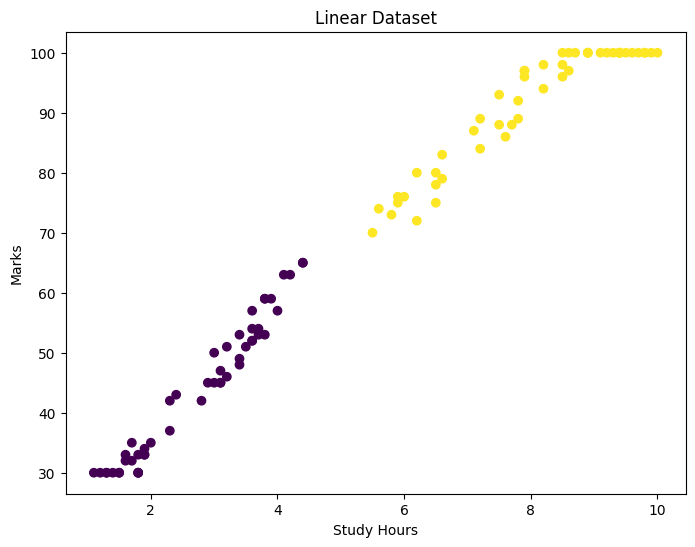

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df["Study_Hours"],df["Marks"],c=y)
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Dataset")
plt.show()

In [10]:
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
model=SVC(kernel="linear")
model.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
y_pred=model.predict(X_test)
print(y_pred)

[0 1 0 0 1 0 0 0 1 0 1 1 1 0 0 1 1 1 1 0]


In [13]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [14]:
cm=confusion_matrix(y_test,y_pred)
cm=pd.DataFrame(cm)
cm


,0,1
0,10,0
1,0,10


In [16]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [17]:
new_student=pd.DataFrame({"Study_Hours":[8],"Marks":[90]})

In [19]:
prediction=model.predict(new_student)
if prediction[0]==1:
    print("Pass")
else:
    print("Fail")

Pass


In [20]:
! pip install mlxtend

     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     - -------------------------------------- 0.0/1.4 MB 653.6 kB/s eta 0:00:03
     --- ------------------------------------ 0.1/1.4 MB 1.4 MB/s eta 0:00:01
     ----- ---------------------------------- 0.2/1.4 MB 1.3 MB/s eta 0:00:01
     ------ --------------------------------- 0.2/1.4 MB 1.2 MB/s eta 0:00:01
     --------- ------------------------------ 0.3/1.4 MB 1.4 MB/s eta 0:00:01
     ---------- ----------------------------- 0.4/1.4 MB 1.4 MB/s eta 0:00:01
     ------------- -------------------------- 0.5/1.4 MB 1.3 MB/s eta 0:00:01
     ---------------- ----------------------- 0.6/1.4 MB 1.5 MB/s eta 0:00:01
     ------------------ --------------------- 0.6/1.4 MB 1.4 MB/s eta 0:00:01
     --------------------- ------------------ 0.7/1.4 MB 1.5 MB/s eta 0:00:01
     ----------------------- ---------------- 0.8/1.4 MB 1.6 MB/s eta 0:00:0

Text(0.5, 1.0, 'Linear SVM Decision Boundary')

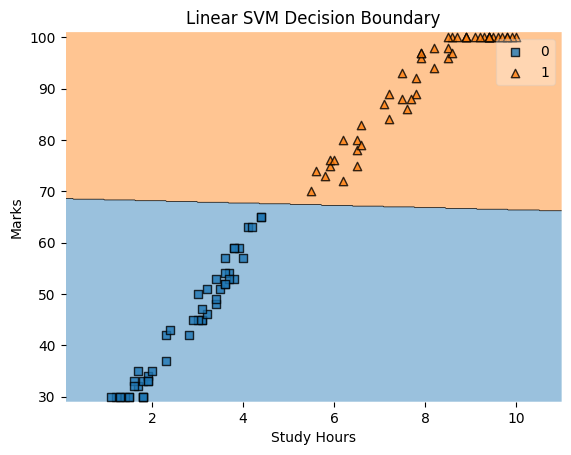

In [22]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
X_plot=X.values
y_plot=y.values
plot_decision_regions(X_plot,y_plot, clf=model)
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear SVM Decision Boundary")
